In [18]:
import dill
import matplotlib.pyplot as plt

from losses import *
from plotting import *
from geometry_alt import minimal_in_H3_PDE

from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget

In [19]:
# load the model
trained_models_path = 'pre-trained models/'
# trained_models_path = 'pre-trained models\'

with open(trained_models_path + 'cassini_1.dill', 'rb') as f:
    model = dill.load(f)

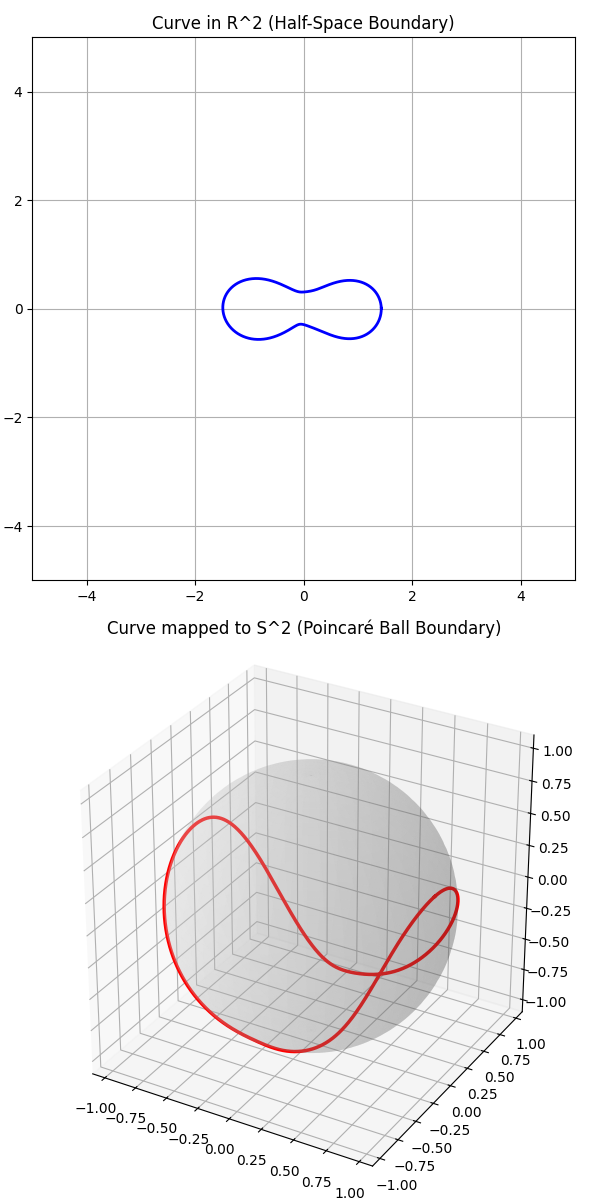

In [20]:
# show the knot
curve = model.curve
plot_curve_and_projection(curve)

MSE: 3.245488187531009e-05


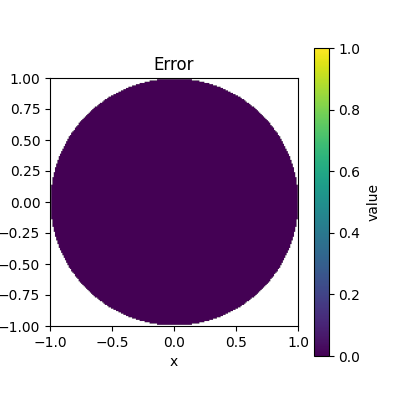

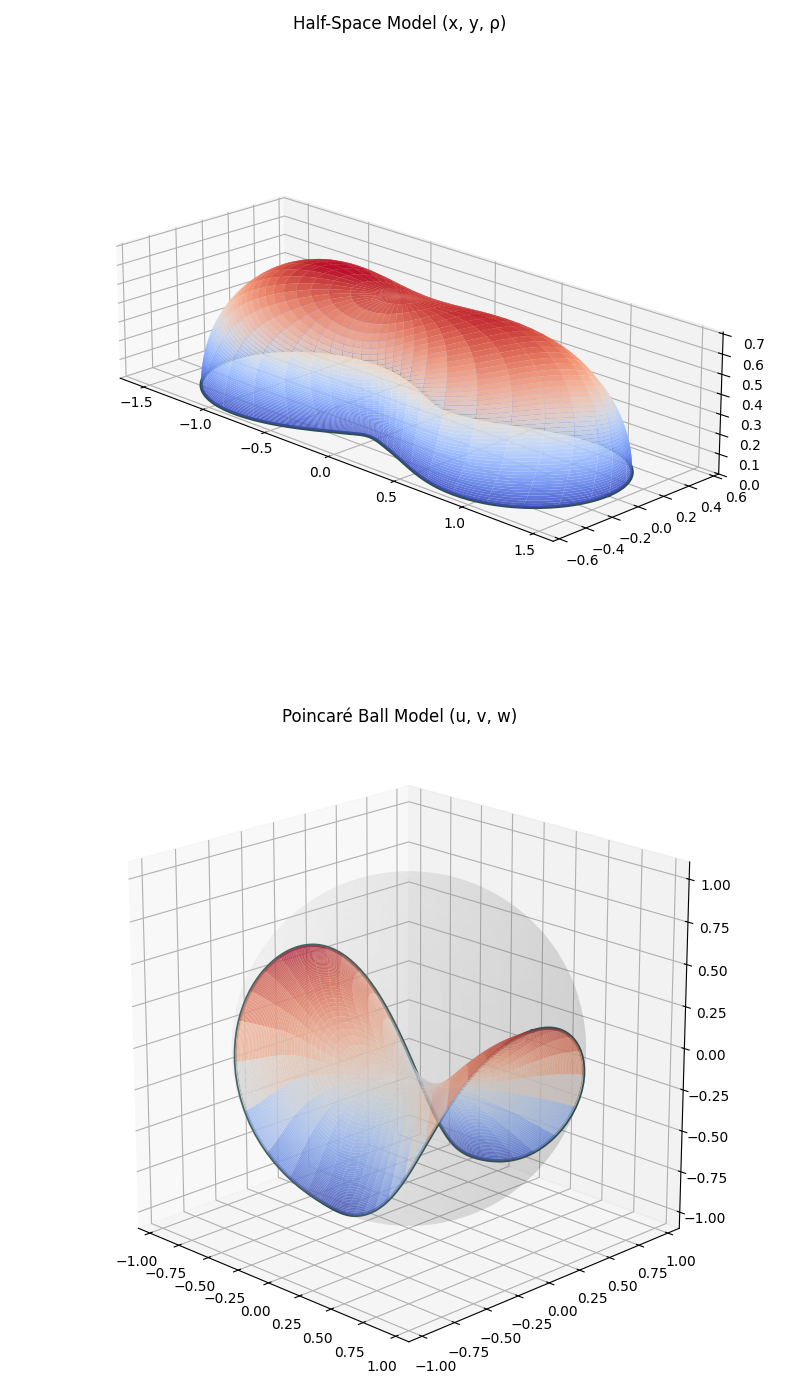

In [24]:
# compute the squared L2 error
xy = sample_unit_disc(N=100000)
t = minimal_in_H3_PDE(model)(xy)

print('MSE:', L2_squared(t).detach().item())

# plot the error on a regular grid
plot_error(
    model,
    vmax=1,
    grid_size=200)

# plot 3d projections
plot_H3_surfaces(
    model_A=model, 
    model_B=model, # not shown
    alpha_B=0, # don't want to see model_B
    grid_size_A=200, 
    min_r_A = 0,
    max_r_A = 1,
    min_theta_A = 0,
    max_theta_A = 2*np.pi,
    alpha_A = 0.9,
    )

In [22]:
# # monte-carlo simulation of the MSE
# n_iterations = 1000
# points_per_sample = 1000

# errors = []
# for i in range(1, n_iterations + 1):
#     if i % (n_iterations // 10) == 0:
#         print(f'{(i / n_iterations) * 100:.0f}% done...')
    
#     # Use the variable here instead of a hardcoded number
#     xy = sample_unit_disc(N=points_per_sample) 
#     t = minimal_in_H3_PDE(model)(xy)
#     errors.append(L2_squared(t).detach().item())

In [23]:
# plt.figure()
# plt.hist(errors, bins=50)
# plt.show()